## 📦 WindFarmNetwork

**Concepts:** [Graph model](../problem.md#the-graph-model) · [Routers](../routers.md)

This notebook is a practical guide to _OptiWindNet_'s Network/Router API (i.e. high-level API). It covers creating a wind farm model, using different routers ([EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter), [HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter), [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter)), and applying the key [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) methods.

### The two classes

[WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) is the **central user-facing component** of the Network/Router API. It holds the problem instance and, after optimization, its solution. It supports multiple input formats and routers, and its constructor arguments are documented in the API Reference under [optiwindnet.api.WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork). The accepted input formats are described in [Input Formats](../reference/input_formats.md).

A [Router](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.Router) computes the network. Given the layout, the available cables and the routing constraints, it determines _which turbines connect to which substations_ and how the cables should be laid to _minimize length (and consequently cost)_. The three built-in routers correspond to the optimization approaches described in [Optimization approaches](../routers.md#optimization-approaches); [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) is the default.

### Set up a network

We create a small wind farm (5 turbines and 1 substation), optimize it with a heuristic and then with a MILP router, and go through the methods of [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork).

Import required modules

In [1]:
import numpy as np

from optiwindnet.api import EWRouter, MILPRouter, ModelOptions, WindFarmNetwork

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

OptiWindNet operates on location geometries, which define turbine and substation positions (plus optional borders/obstacles).

You can load a location from:

- `.yaml` or `.osm.pbf` files;
- The included locations repository;
- Your own coordinate arrays.

For more details see [Data Input](hi11_data_input.ipynb).

We start with a simple geometry (5 turbines and 1 substation), and define a simple set of cables.

In [3]:
wfn = WindFarmNetwork(
    cables=[(2, 1500.0), (5, 1800.0)],
    turbinesC=np.array([[0, 0], [1, 1], [2, 0], [3, 1], [4, 0]]),
    substationsC=np.array([[2, -2]]),
    borderC=np.array([[0, -3], [0, 2], [4, 2.1], [5, 1], [4, -3]]),
    obstacleC_=[np.array([[0.2, -2.5], [1.5, -2.5], [0.2, -1]])],
)

Plot the location to confirm the data was loaded as intended.

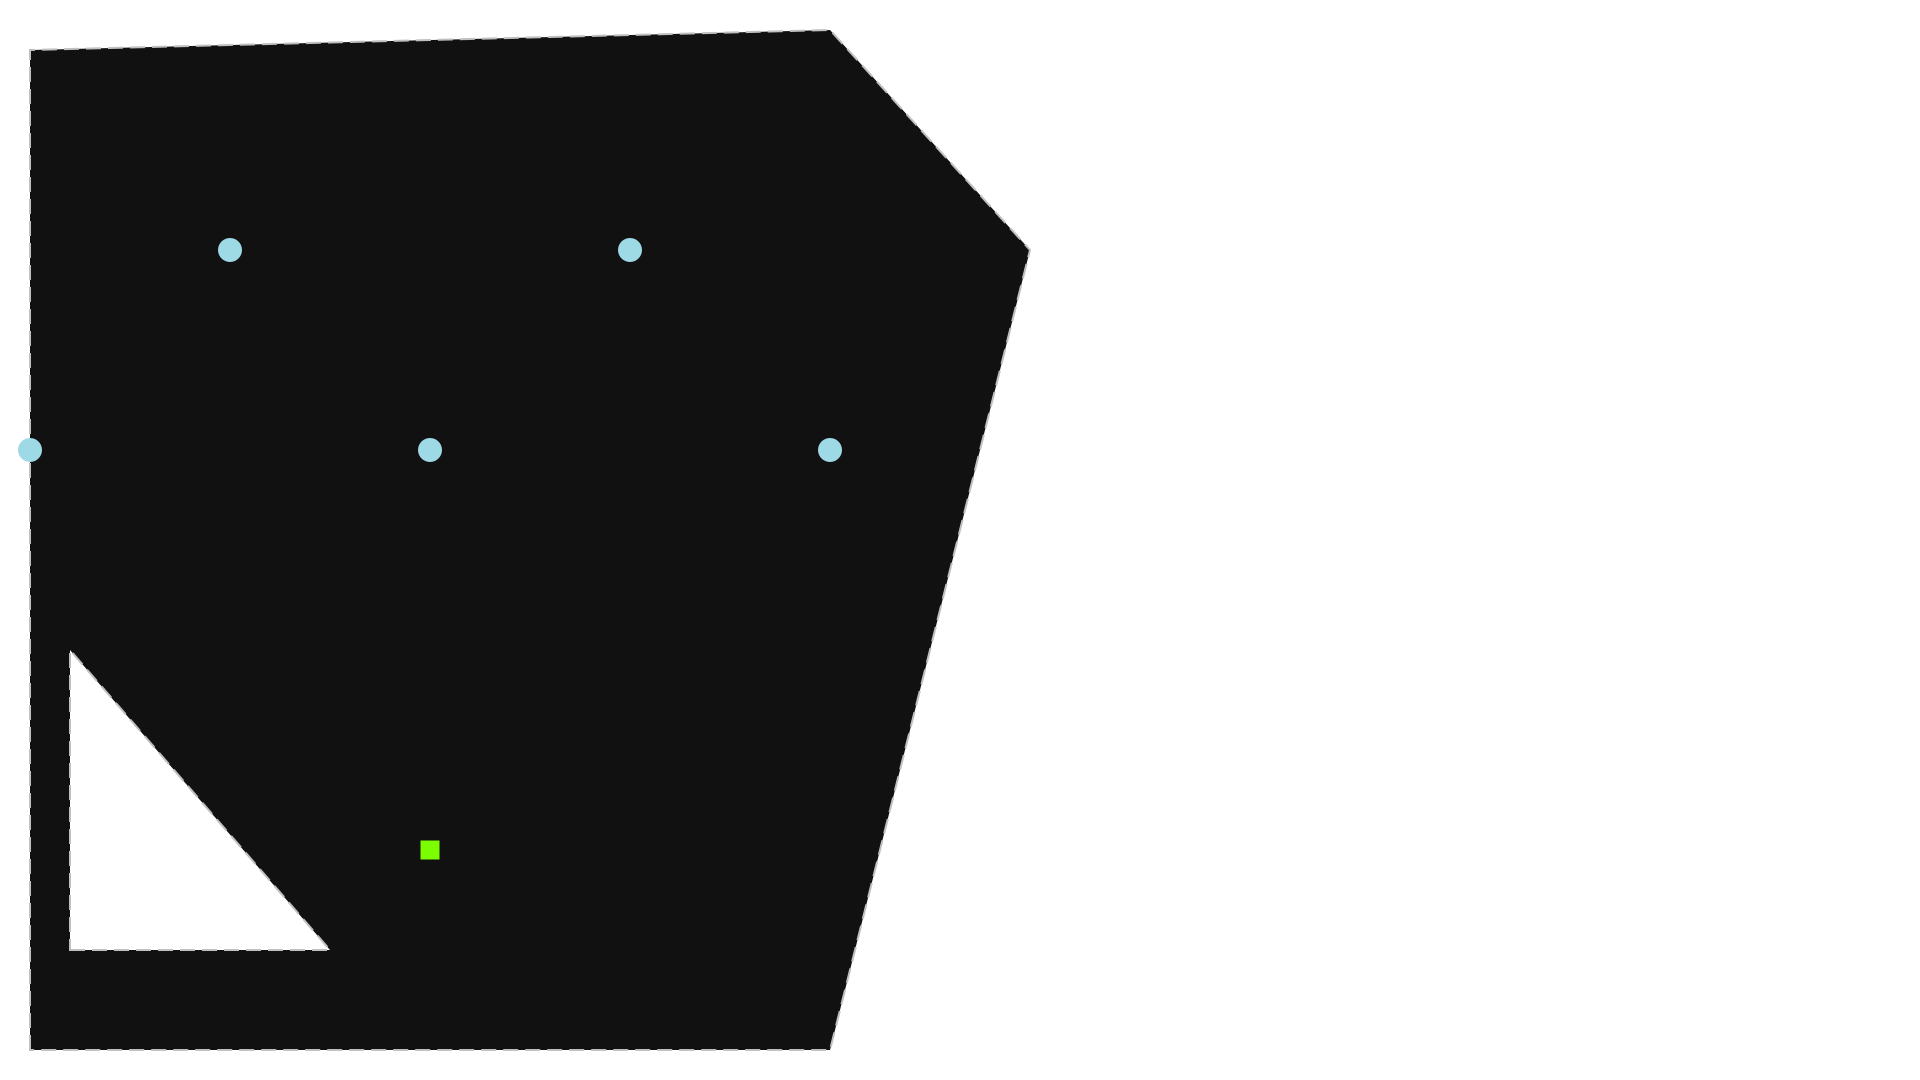

In [4]:
wfn

### Optimize

This is the main method that optimizes the electrical network using the given router (heuristic, meta-heuristic or MILP).

> Note that the router could be passed directly to `WindFarmNetwork(router=...)`.

#### With a heuristic router (Esau-Williams)

In [5]:
wfn.optimize(router=EWRouter())

TerseLinks(scope='topology', topology='branched', T=5, R=1, links=5)

Plot the result

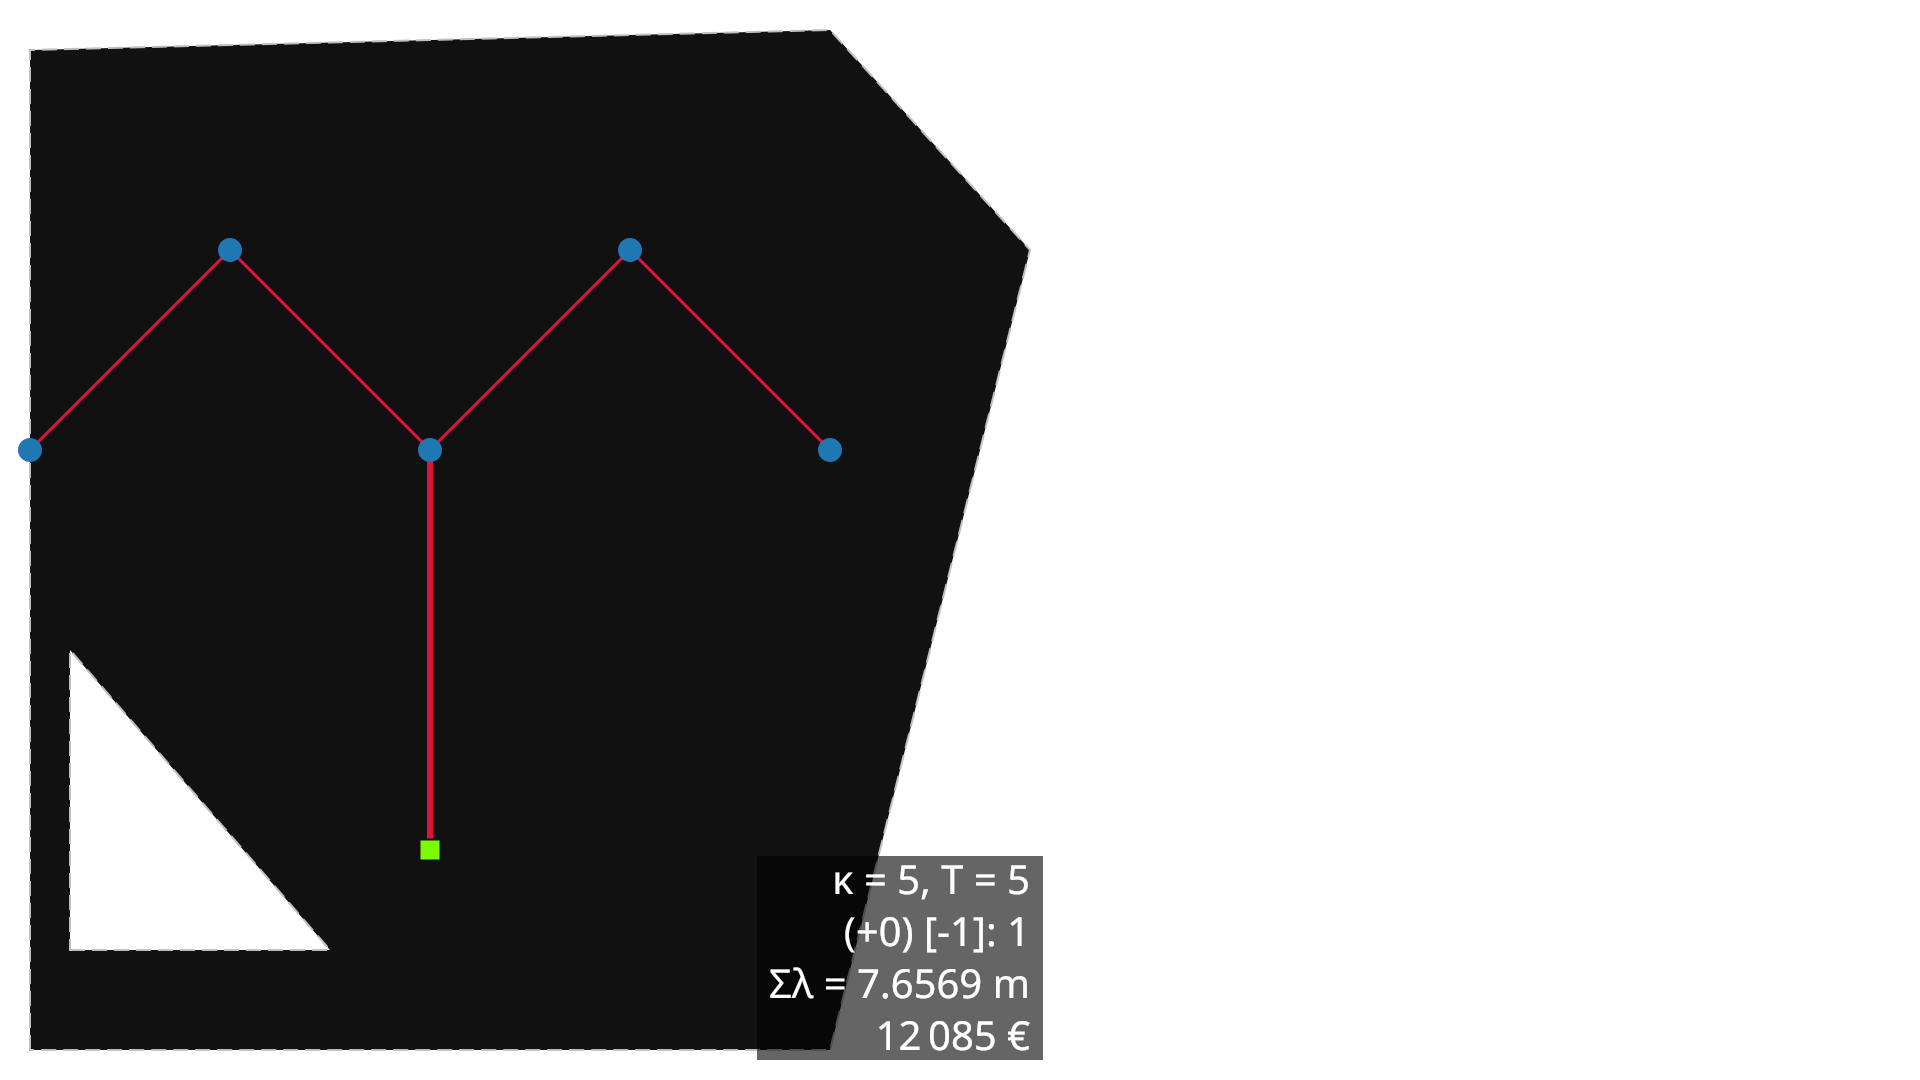

In [6]:
wfn

#### With a MILP router

The solution from the previous call to [wfn.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) is stored within the `wfn` object. If this solution is _feasible under the current [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) settings_, it will be _automatically used as a warm start_. Otherwise, if it does not meet the current [ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions) constraints, it will be _ignored_, and the MILP solver will start from scratch — see [Warm-starting](../routers.md#warm-starting).

IntegerBoundsPreprocessor                              85 rows, 46 columns, 267 entries with magnitude in [1.000000e+00, 5.000000e+00]
BoundPropagationPreprocessor                           85 rows, 46 columns, 267 entries with magnitude in [1.000000e+00, 5.000000e+00]
ImpliedIntegerPreprocessor                             85 rows, 46 columns, 267 entries with magnitude in [1.000000e+00, 5.000000e+00]
IntegerBoundsPreprocessor                              85 rows, 46 columns, 267 entries with magnitude in [1.000000e+00, 5.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        85 rows, 46 columns, 267 entries with magnitude in [1.000000e+00, 5.000000e+00]

Scaling to pure integer problem.
Num integers: 23/46 (implied: 0 in_inequalities: 0 max_scaling: 0) [MIP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 2 log_search

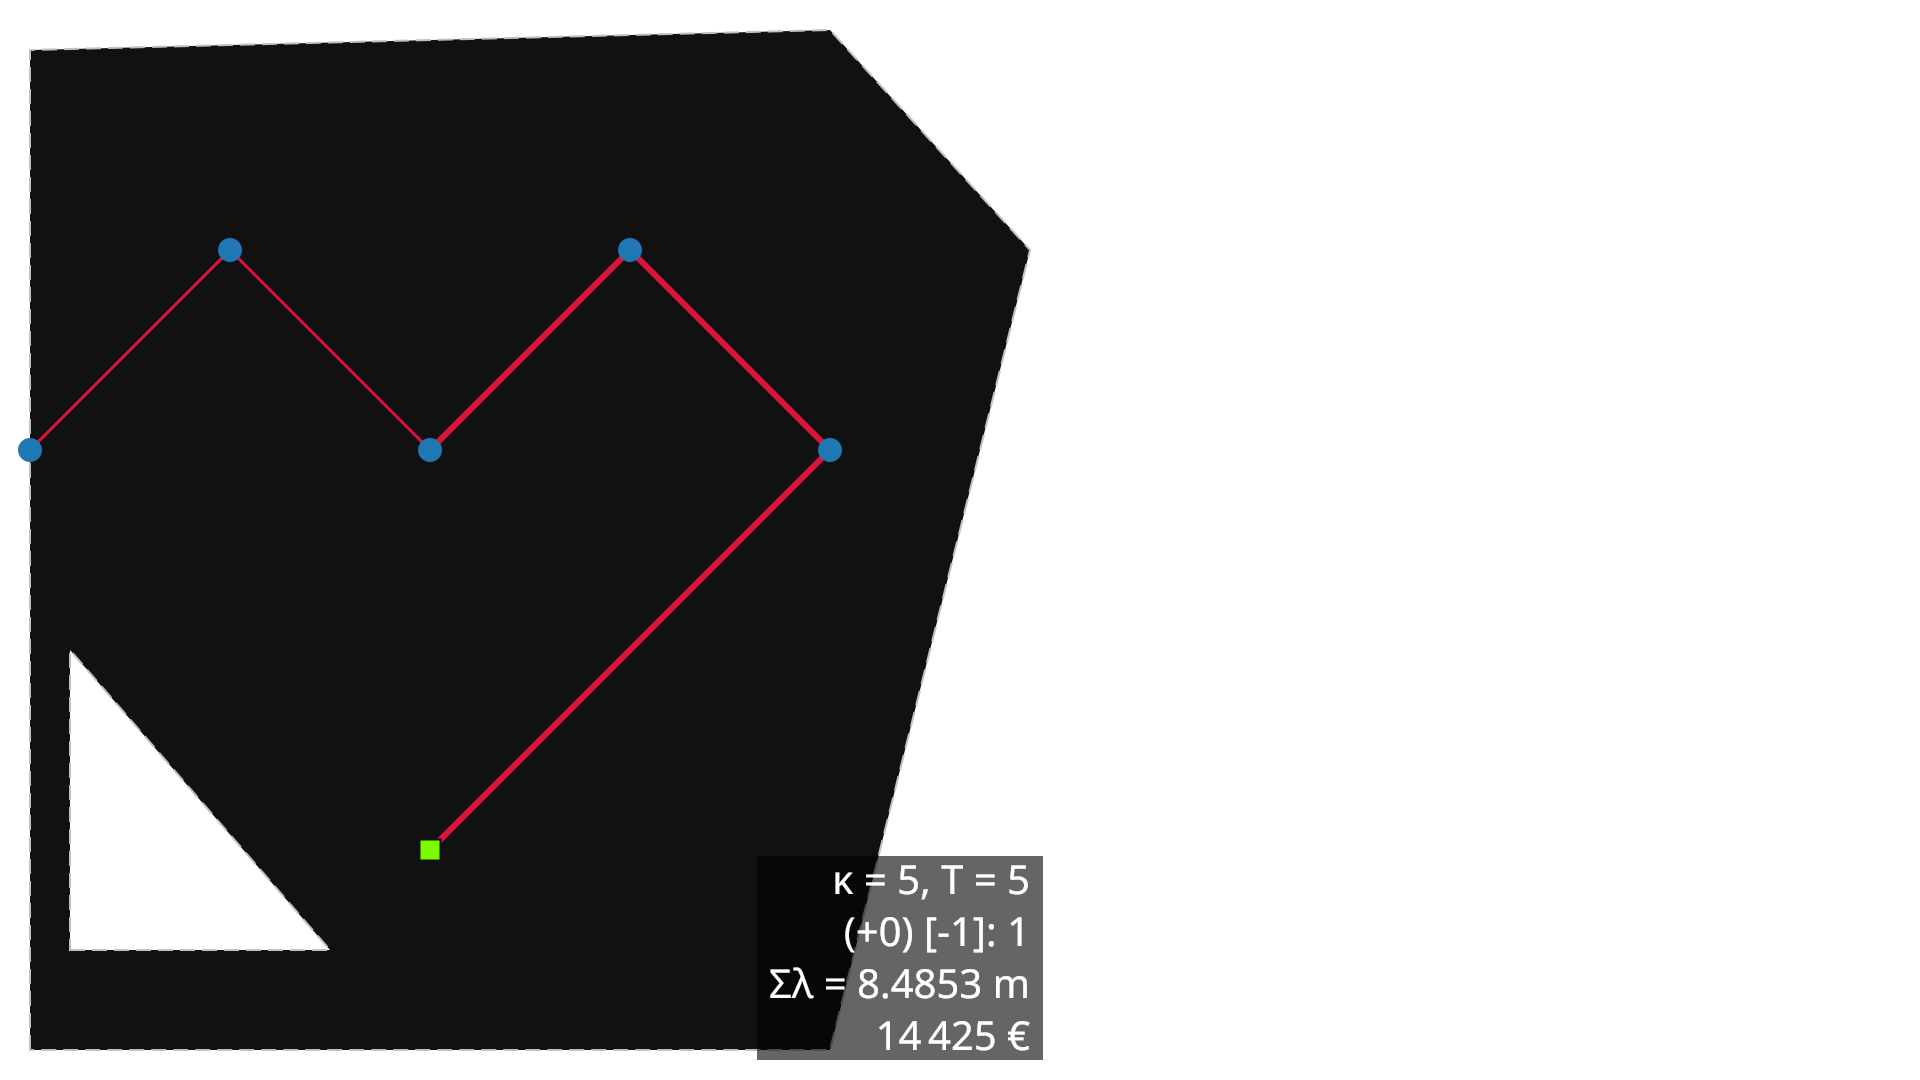

In [7]:
model_opts = ModelOptions(
    topology='radial',
    feeder_limit='minimum',
    feeder_route='straight',
)
wfn.optimize(
    router=MILPRouter(
        solver_name='ortools.cp_sat',
        time_limit=2,
        mip_gap=0.01,
        model_options=model_opts,
    ),
    verbose=True,
)
wfn

### Methods

#### `plot()` and variants

These methods help you visualize different stages of the optimization:

- [plot_location()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_location): plot turbine/substation coordinates and borders
- [plot()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot): plot optimized electrical network

> For more details, see the [Plotting](hi14_plotting.ipynb) tutorial.

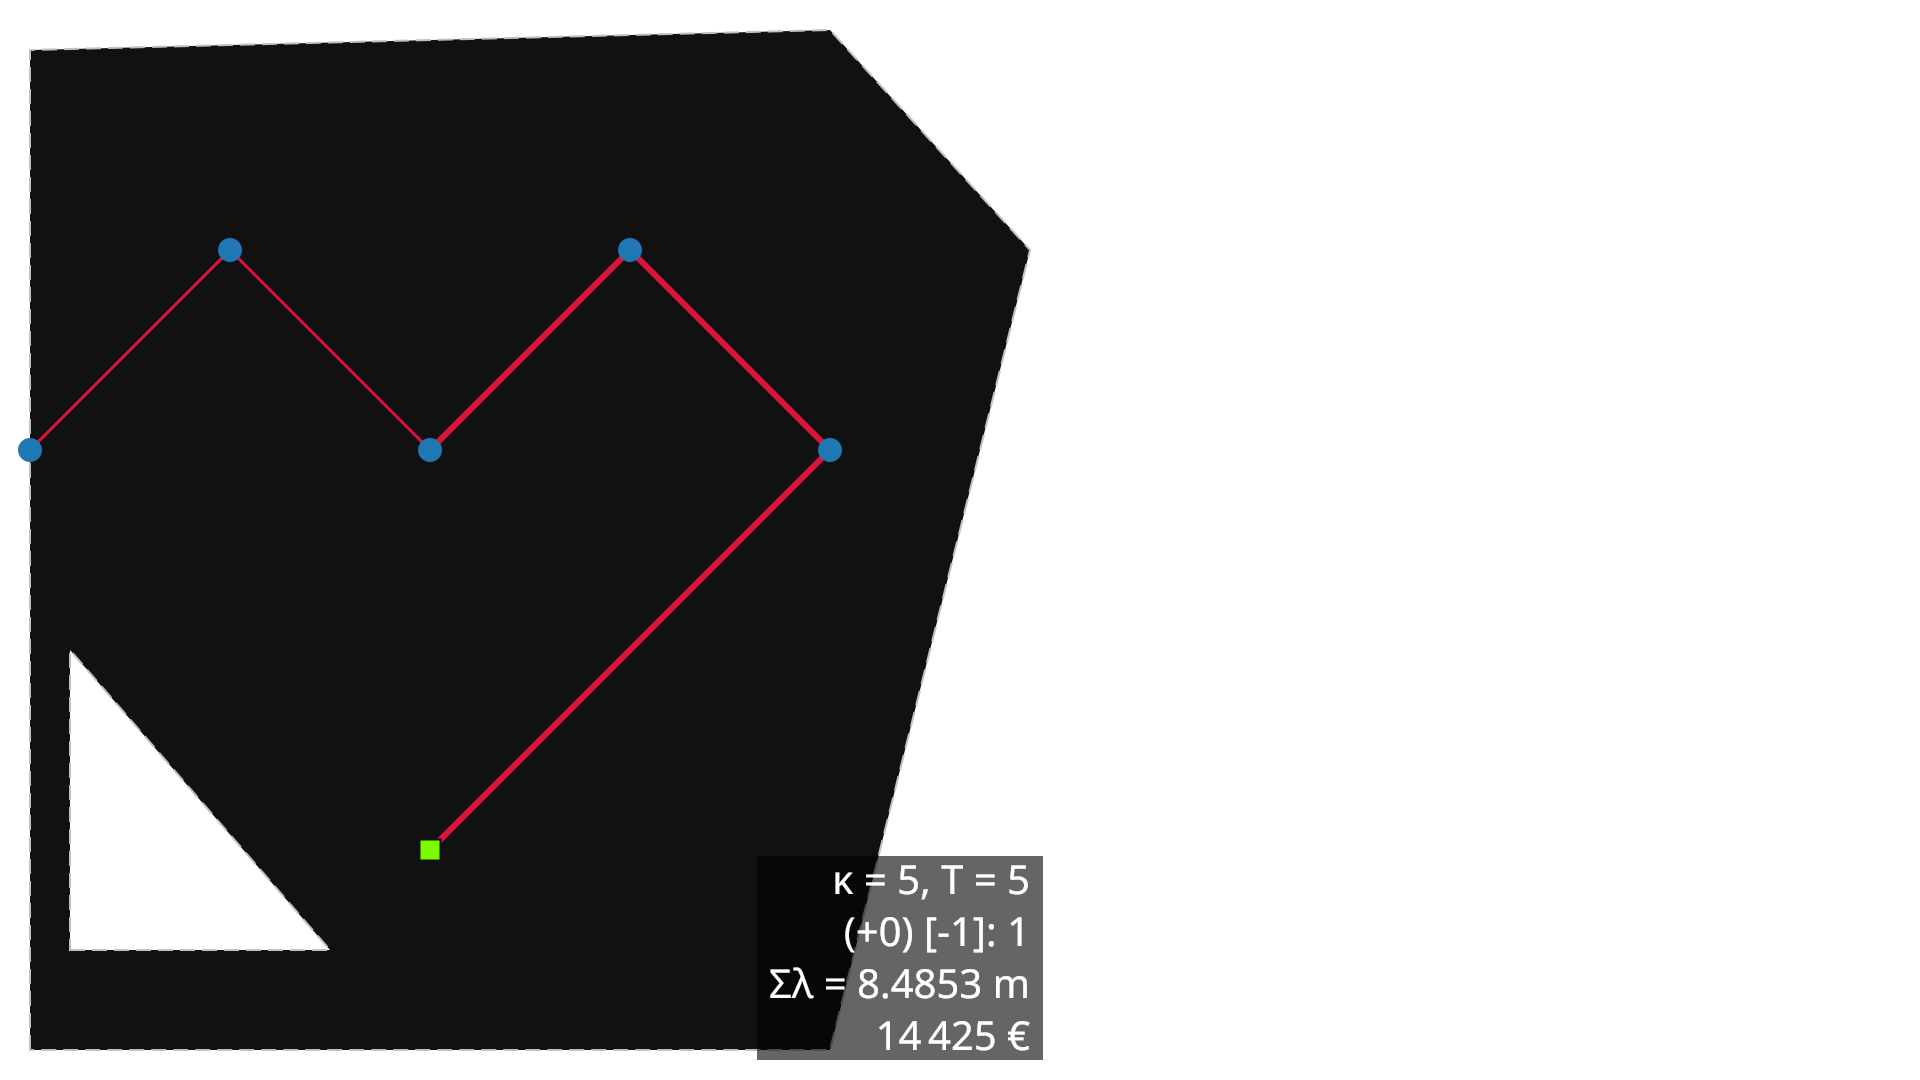

In [8]:
wfn.plot_location()
# wfn will do the same on notebooks (and if no G is available it will display L)
wfn.plot()

#### `cost()` and `length()`

Returns the total cost and cable length of the optimized network.

In [9]:
print('Network cost:', wfn.cost())
print('Network length:', wfn.length())

Network cost: 14424.97833620557
Network length: 8.485281374238571


#### `terse_links()` and `update_from_terse_links()`

[terse_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.terse_links) returns a [TerseLinks](../autoapi/optiwindnet/terse/index.rst#optiwindnet.terse.TerseLinks) object: a NumPy-compatible array carrying the network's `radial`, `branched`, or `ringed` topology architecture. Keeping this metadata with the array ensures that reconstructing a network preserves its architecture. For positional radial and branched encodings:

- Each position `i` represents turbine `i`

- The value at position `i` is the node that turbine `i` connects to (this could be another turbine or a substation)

In [10]:
terse = wfn.terse_links()
print('Topology-aware terse links:', repr(terse))

Topology-aware terse links: TerseLinks(scope='topology', topology='radial', T=5, R=1, links=5)


[update_from_terse_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.update_from_terse_links) reconstructs the network from known terse links:

[update_from_terse_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.update_from_terse_links) allows you to reconstruct the network from known terse links, optionally updating coordinates. A [TerseLinks](../autoapi/optiwindnet/terse/index.rst#optiwindnet.terse.TerseLinks) value returned by OptiWindNet already carries its topology. When supplying a plain list or NumPy array, pass `topology='radial'`, `'branched'`, or `'ringed'` explicitly so the architecture is preserved. This method assumes a **valid and feasible network**, so it’s your responsibility to ensure that:

- The connections conform to the declared topology architecture
- Every turbine is (indirectly or directly) connected to a **substation**
- Capacity constraints are not violated

Suppose we have a wind farm with:

- **5 turbines** nodes `0, 1, 2, 3, 4`
- **1 substation** node `-1` (_Note: In OptiWindNet, substations are assigned negative indices_)

We want the following connections:

- Turbine 0 Substation (-1)
- Turbine 1 Turbine 0
- Turbine 2 Substation (-1)
- Turbine 3 Turbine 2
- Turbine 4 Turbine 3

This gives us the [terse_links](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.terse_links) array:

```python
terse_links = [-1, 0, -1, 2, 3]
```

Because this is a plain array rather than a [TerseLinks](../autoapi/optiwindnet/terse/index.rst#optiwindnet.terse.TerseLinks) object, the update call below declares that its two feeders are radial paths.

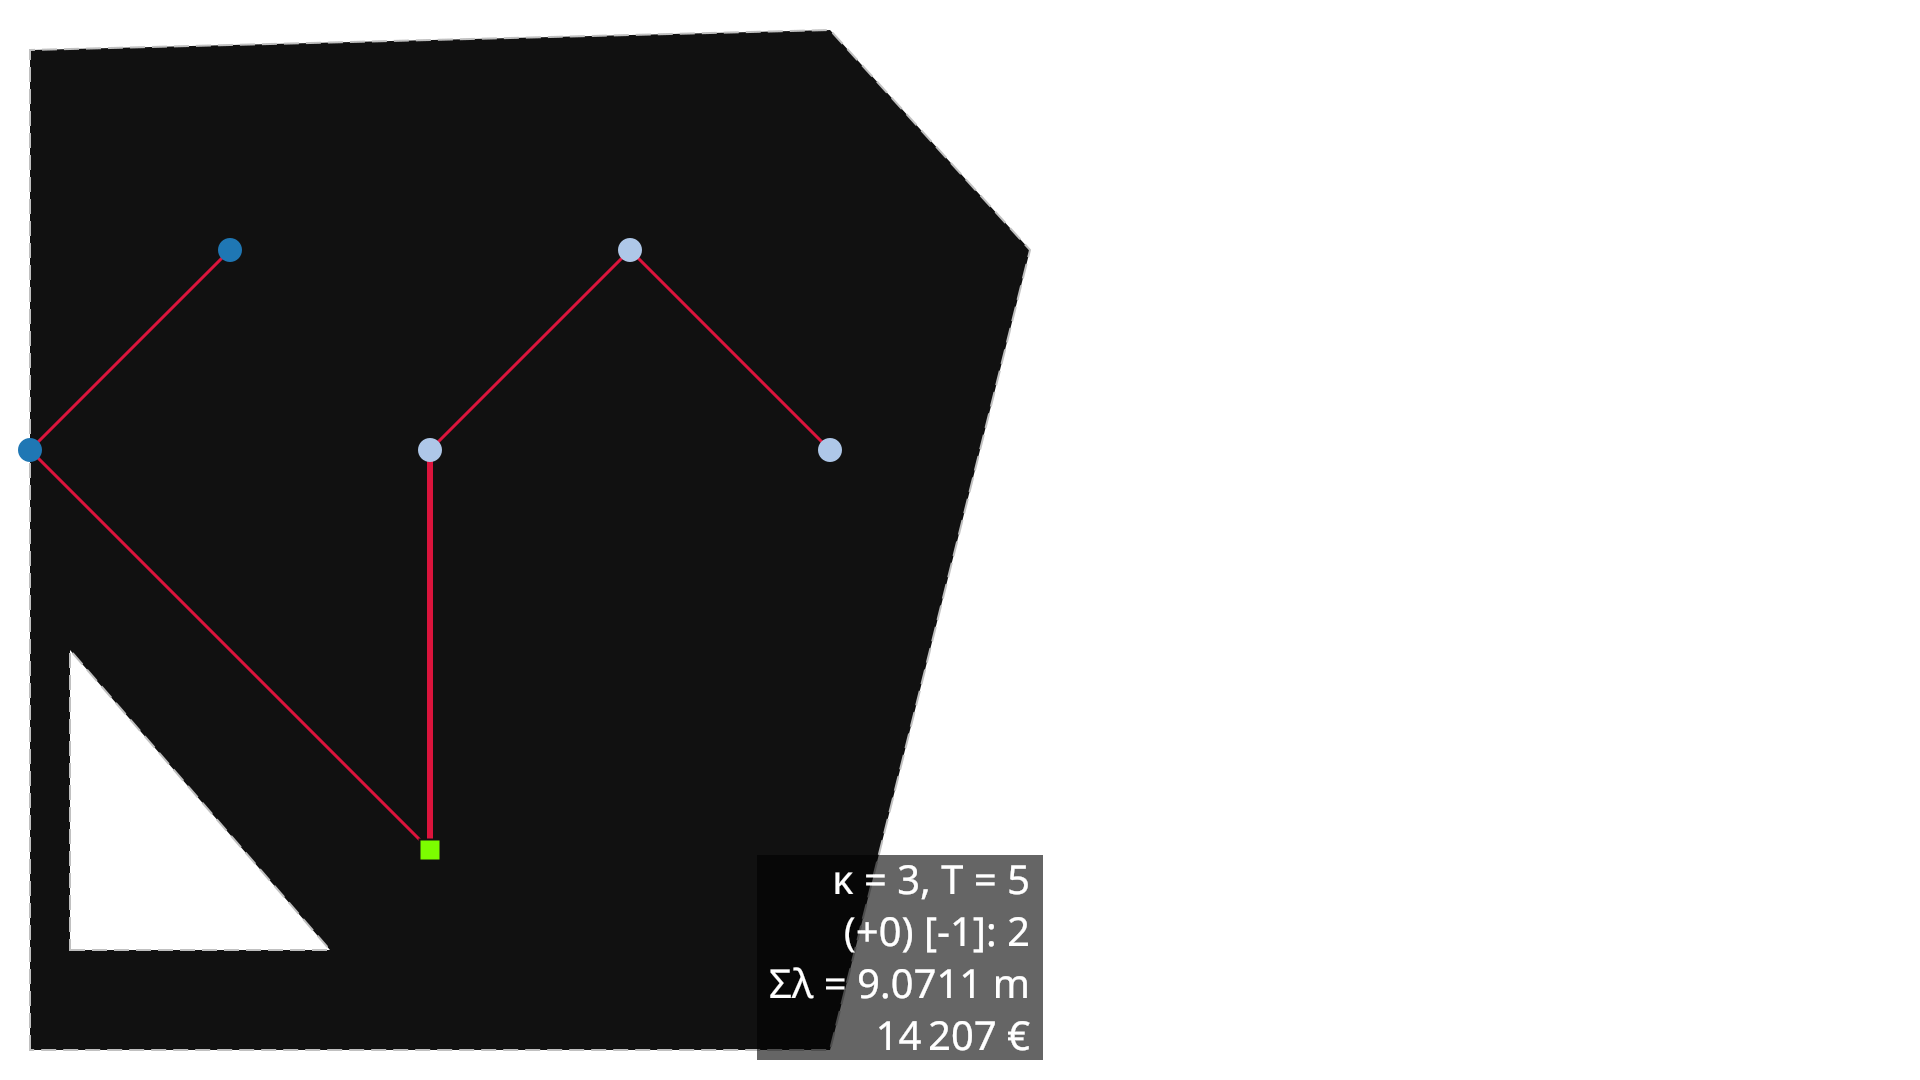

In [11]:
new_terse_links = np.array([-1, 0, -1, 2, 3])

# Apply the new configuration
wfn.update_from_terse_links(new_terse_links, topology='radial')

# Visualize the updated network (cable routing)
wfn

#### `gradient()`

This method computes the gradient of the cost or length with respect to turbine/substation positions. Useful for hybrid optimization or sensitivity analysis.

> Note: default of `gradient_type` is `length`.

In [12]:
print('--- gradient_type=length ---\n')
grad_turb, grad_subs = wfn.gradient()
print('Gradient (w.r.t. turbines):\n', grad_turb, '\n')
print('Gradient (w.r.t. substations):\n', grad_subs)
print('\n')
print('--- gradient_type=cost ---\n')
grad_turb, grad_subs = wfn.gradient(gradient_type='cost')
print('Gradient (w.r.t. turbines):\n', grad_turb, '\n')
print('Gradient (w.r.t. substations):\n', grad_subs)

--- gradient_type=length ---

Gradient (w.r.t. turbines):
 [[-1.41421356  0.        ]
 [ 0.70710678  0.70710678]
 [-0.70710678  0.29289322]
 [ 0.          1.41421356]
 [ 0.70710678 -0.70710678]] 

Gradient (w.r.t. substations):
 [[ 0.70710678 -1.70710678]]


--- gradient_type=cost ---

Gradient (w.r.t. turbines):
 [[-2121.32034356     0.        ]
 [ 1060.66017178  1060.66017178]
 [-1060.66017178   739.33982822]
 [    0.          2121.32034356]
 [ 1060.66017178 -1060.66017178]] 

Gradient (w.r.t. substations):
 [[ 1060.66017178 -2860.66017178]]


#### `get_network()`

This method returns the **final optimized network** as a **structured NumPy array**, where each row represents an edge in the network.

Each edge includes detailed attributes such as:

- **`src`**: index of the source node
- **`tgt`**: index of the target (destination node)
- **`length`**: physical cable length
- **`load`**: electrical load carried through the cable (number of turbines)
- **`cable`**: index of the cable type used (e.g., 0 for first type in cable list)
- **`cost`**: cost associated with the used cable (if cost is provided by the user)

In [13]:
network_data = wfn.get_network()
network_data[:2]  # preview only first few edges

array([(0, -1, 2.82842712, 2., 0), (2, -1, 2.        , 3., 1)],
      dtype=[('src', '<i8'), ('tgt', '<i8'), ('length', '<f8'), ('load', '<f8'), ('cable', '<i8')])

#### `add_buffer()`

This method redefines the border and obstacles by expanding the borders and shrinking the obstacles; useful when turbines are near edges or when integrating with tools like TopFarm|

In [14]:
wfn.add_buffer(buffer_dist=0.5)

Buffering by 0.50 completely removed the obstacle at index 0. For visual comparison use plot_original_vs_buffered().


<Axes: title={'center': 'Original and Buffered Shapes'}>

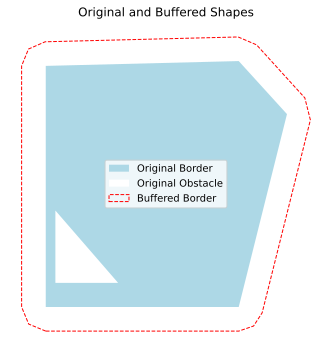

In [15]:
wfn.plot_original_vs_buffered()

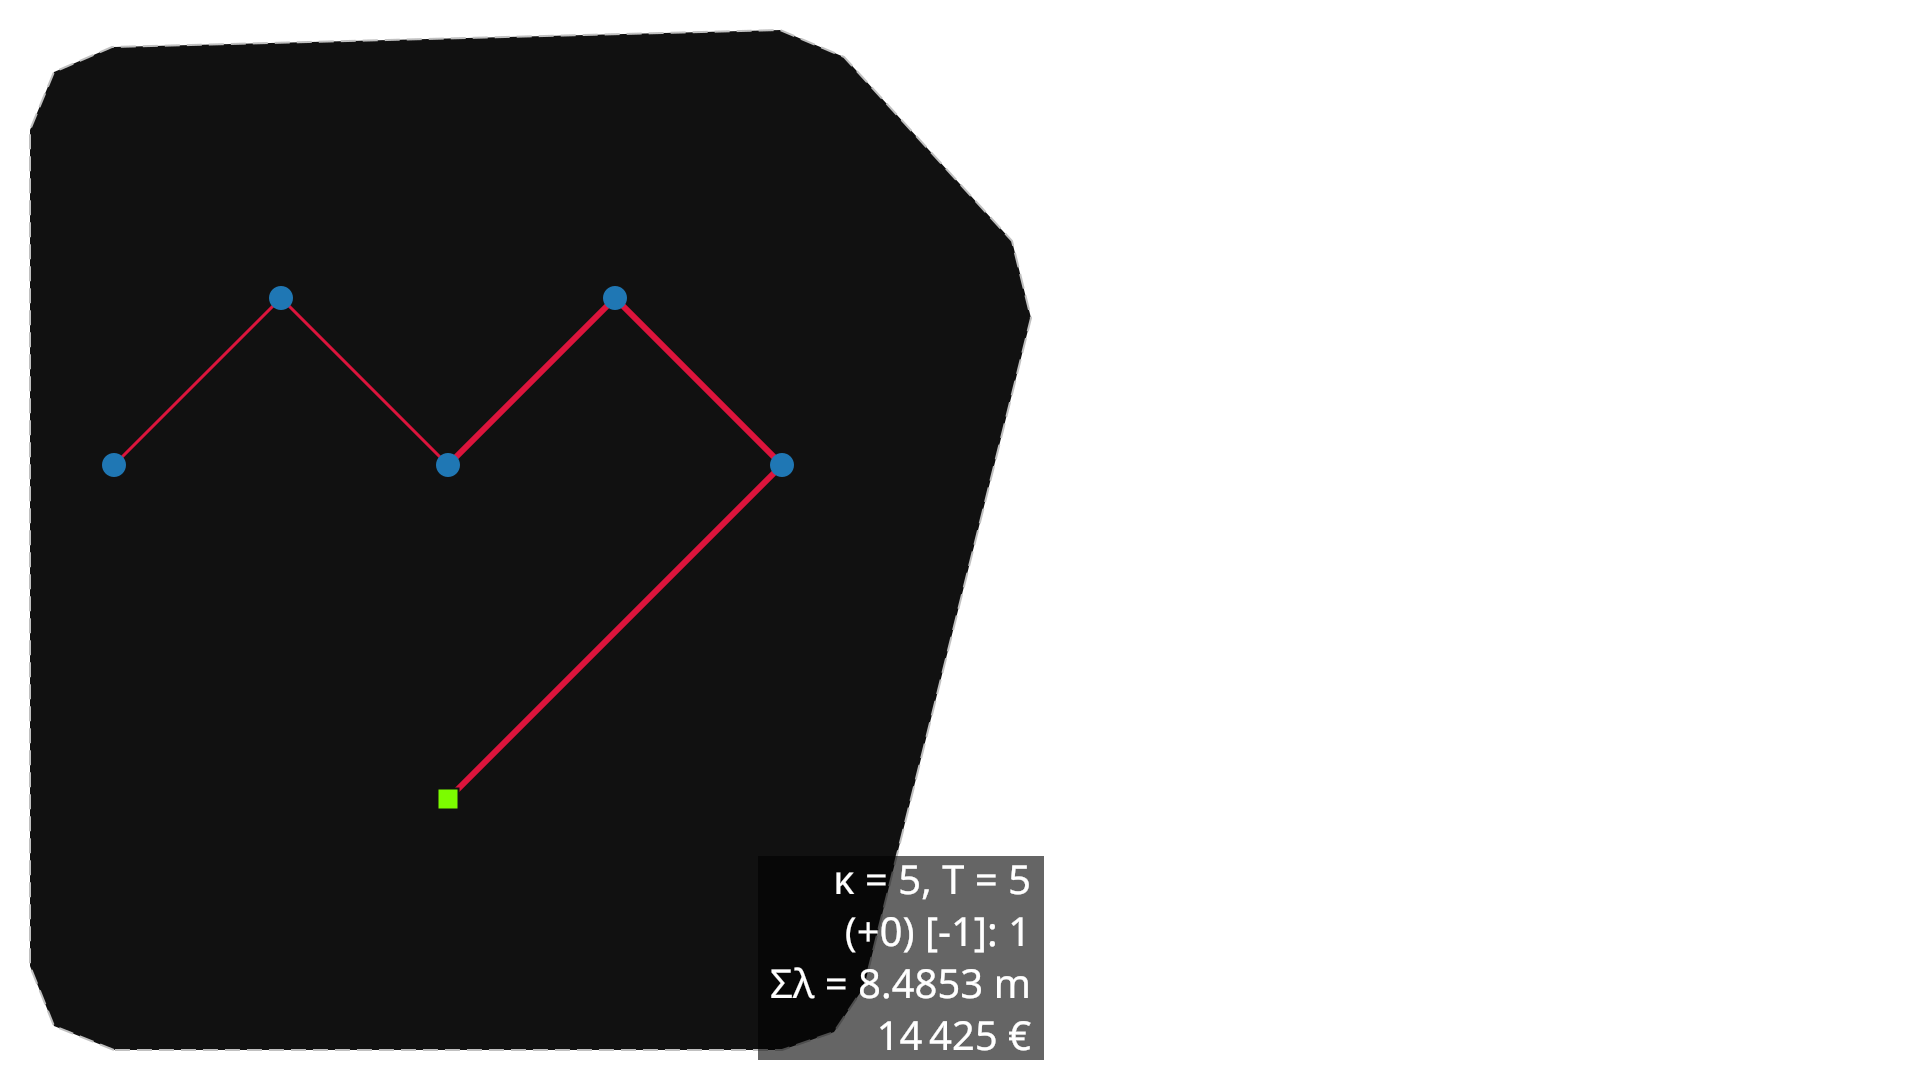

In [16]:
wfn.optimize()
wfn

### Summary

We explored the most useful methods of the [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) class:

| Method | Purpose |
| --- | --- |
| [optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) | Run optimization with a router |
| [plot()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot) | Visualize the network |
| [cost()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.cost), [length()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.length) | Get total cost and length |
| [terse_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.terse_links) | Get compact links with their topology architecture |
| [update_from_terse_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.update_from_terse_links) | Apply topology-aware terse links manually |
| [gradient()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.gradient) | Compute network's gradient |
| [get_network()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.get_network) | Export the optimized network data |
| [add_buffer()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.add_buffer) | Expand border - Shrink obstacles |

For deeper insights into individual methods, refer to the dedicated notebooks provided.